# EDA: dev_set.csv

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
pd.set_option('display.max_colwidth', 80)


In [2]:
df = pd.read_csv('../data/dev_set.csv')
df.shape

(94825, 3)

In [3]:
df.head()

,context,first letter,answer
0,south korea and the united states on monday warned north korea to avoid prov...,d,day
1,"after agreeing to drastically cut its car import duties , taiwan on thursday...",t,the
2,three soldiers were injured in a bombing ambush launched by suspect thai sou...,m,morning
3,an aviation official says a yemeni investigation team has found that a yemen...,w,was
4,"the movement for democracy in liberia - lrb - model - rrb - , the second lar...",t,to


## Basic info

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94825 entries, 0 to 94824
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   context       94825 non-null  str  
 1   first letter  94825 non-null  str  
 2   answer        94825 non-null  str  
dtypes: str(3)
memory usage: 2.2 MB


In [5]:
df.isna().sum()

context         0
first letter    0
answer          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(5229)

## Context length distribution (words / chars)

In [7]:
df['ctx_word_len'] = df['context'].str.split().str.len()
df['ctx_char_len'] = df['context'].str.len()
df[['ctx_word_len','ctx_char_len']].describe()

,ctx_word_len,ctx_char_len
count,94825.000000,94825.000000
mean,24.953873,137.407878
std,6.913255,36.675342
min,8.000000,28.000000
25%,21.000000,114.000000
50%,24.000000,137.000000
75%,29.000000,159.000000
max,81.000000,366.000000


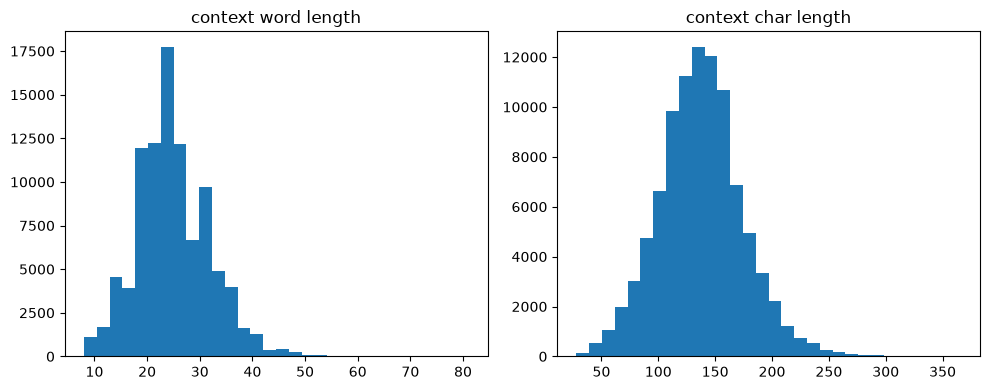

In [8]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(df['ctx_word_len'], bins=30); ax[0].set_title('context word length')
ax[1].hist(df['ctx_char_len'], bins=30); ax[1].set_title('context char length')
plt.tight_layout(); plt.show()

## First letter distribution

In [9]:
df['first letter'].value_counts()

first letter
t    12934
a     9921
s     6751
o     5609
i     5253
,     4722
c     4638
f     4016
p     3899
w     3616
b     3465
m     2995
r     2811
h     2790
d     2641
-     2256
l     2231
1     2090
e     2067
n     1780
g     1374
'     1246
u     1208
.      806
k      562
y      559
v      527
j      519
"      465
[      351
q      202
$      101
z       91
_       90
]       61
U       49
:       48
x       42
\       14
/        7
!        6
&        5
?        3
;        2
@        1
%        1
Name: count, dtype: int64

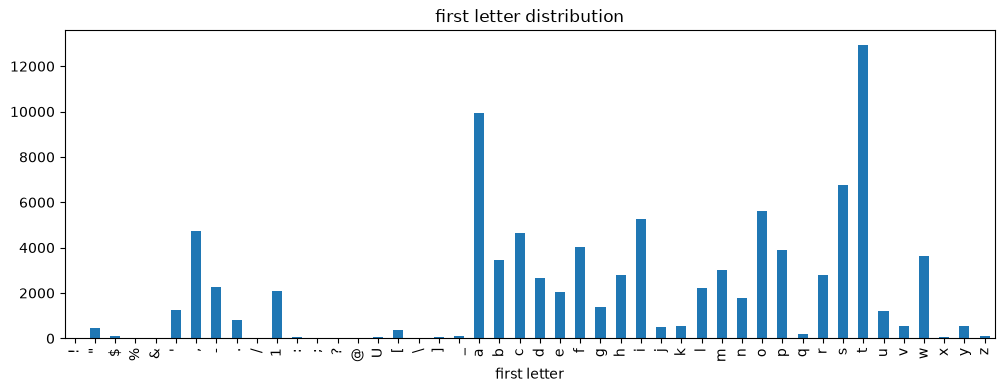

In [10]:
df['first letter'].value_counts().sort_index().plot.bar(figsize=(12,4), title='first letter distribution'); plt.show()

## Answer category: word / number / symbol

In [11]:

def categorize(tok):
    if re.fullmatch(r"[0-9]+", tok):
        return "number"
    if re.fullmatch(r"[a-z']+", tok, re.IGNORECASE):
        return "word"
    return "symbol"


In [12]:
df['answer_cat'] = df['answer'].astype(str).apply(categorize)
df['answer_cat'].value_counts()

answer_cat
word      83783
symbol     9019
number     2023
Name: count, dtype: int64

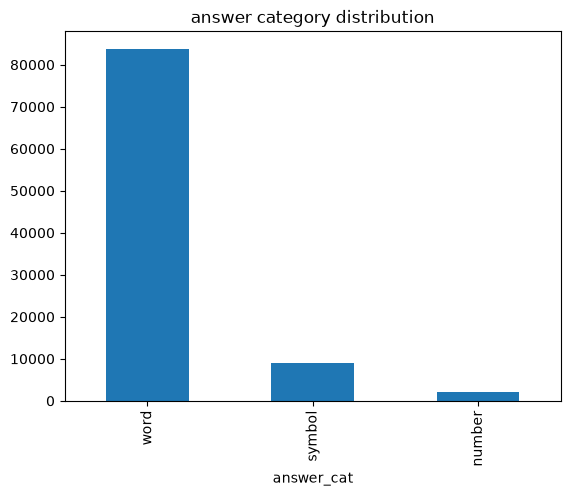

In [13]:
df['answer_cat'].value_counts().plot.bar(title='answer category distribution'); plt.show()

## Answer length distribution

In [14]:
df['answer_len'] = df['answer'].astype(str).str.len()
df['answer_len'].describe()

count    94825.000000
mean         4.440390
std          2.765253
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         18.000000
Name: answer_len, dtype: float64

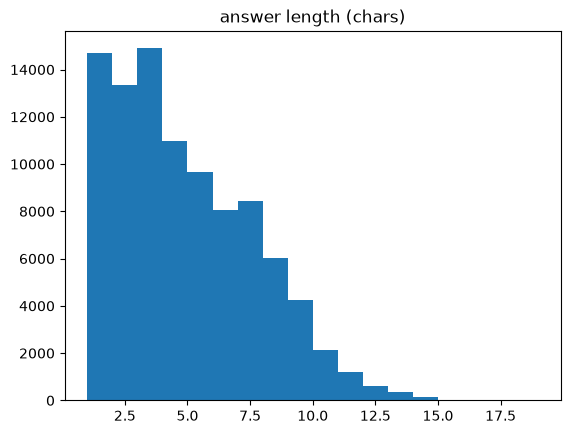

In [15]:
plt.hist(df['answer_len'], bins=range(1, df['answer_len'].max()+2)); plt.title('answer length (chars)'); plt.show()

## Answer first-letter consistency check

In [16]:
mismatch = df[df['answer'].astype(str).str[0] != df['first letter'].astype(str)]
len(mismatch), mismatch.head()

(0,
 Empty DataFrame
 Columns: [context, first letter, answer, ctx_word_len, ctx_char_len, answer_cat, answer_len]
 Index: [])

## Token list for dev (unique answers)

In [17]:
answer_counts = df['answer'].value_counts()
print('unique answers:', answer_counts.shape[0])
answer_counts.head(30)

unique answers: 10310


answer
the      5602
,        4722
of       2770
to       2729
a        2548
in       2358
-        2256
and      1757
'        1246
s        1238
for       960
on        892
.         806
11        802
at        711
that      626
1         621
from      516
with      506
by        485
"         465
an        427
his       424
as        423
111       372
its       336
was       310
after     292
[UNK]     288
lrb       286
Name: count, dtype: int64

In [18]:
answer_counts.tail(30)

answer
rekindled         1
lectures          1
blaine            1
prehistoric       1
secs              1
billboards        1
negotiators       1
mediate           1
freddie           1
pradesh           1
shortens          1
bhp               1
restricts         1
reactivate        1
ejected           1
acknowledgment    1
southernmost      1
astrid            1
comprising        1
sitting           1
stretched         1
eat               1
111s              1
vials             1
porto             1
yuans             1
integrity         1
survivors         1
abused            1
excellent         1
Name: count, dtype: int64

In [19]:
token_list_dev = sorted(answer_counts.index.tolist())
len(token_list_dev)

10310

In [20]:
import json
with open('../data/dev_token_list.json','w') as f:
    json.dump(token_list_dev, f)
print('saved dev_token_list.json')

saved dev_token_list.json


## Context vocabulary (unique tokens appearing in context)

In [21]:
ctx_tokens = pd.Series(' '.join(df['context']).split())
ctx_vocab = ctx_tokens.value_counts()
print('unique context tokens:', ctx_vocab.shape[0])
ctx_vocab.head(30)

unique context tokens: 44431


the      116243
,         73783
-         66667
a         65646
of        62142
to        57028
in        50259
and       36125
s         33693
'         32538
on        30264
.         29395
for       20566
11        19975
1         18042
that      15976
with      12957
at        11430
an        11195
as        11003
has       10429
"         10260
111       10123
by        10093
from       9790
lrb        8947
was        8931
said       8885
[UNK]      8482
will       8359
Name: count, dtype: int64